Day 17 Feature Scaling

In [2]:
'''
Feature Scaling:

Feature scaling is a technique used to standardize the range of independent variables or features of data. In machine learning, it is often necessary to scale features to ensure that they are on the same scale, which can improve the performance of certain algorithms.
Types of Feature Scaling:
1. Min-Max Scaling (Normalization)
2. Standardization (Z-score Normalization)
'''
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Load the dataset
data  = pd.read_excel(r"C:\Users\MUSKAAN\Documents\M.E Folder\ML&AI\Machine Learning Journey\ml-from-basics-to-beyond\Phase_2_Data_Handling\E Commerce Dataset.xlsx", sheet_name="E Comm")
data.head(5)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# We will use Feature - 'CashbackAmount' for scaling
# Check if any null values in the 'CashbackAmount' column
data['CashbackAmount'].isnull().sum()


np.int64(0)

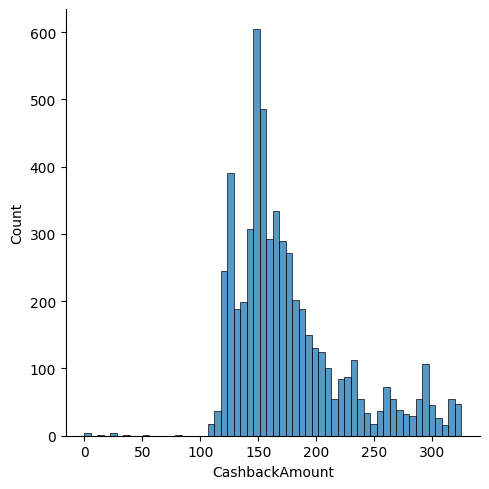

In [4]:
# To plot the distribution of 'CashbackAmount' before scaling
sns.displot(data['CashbackAmount'])
plt.show()

In [5]:
data.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


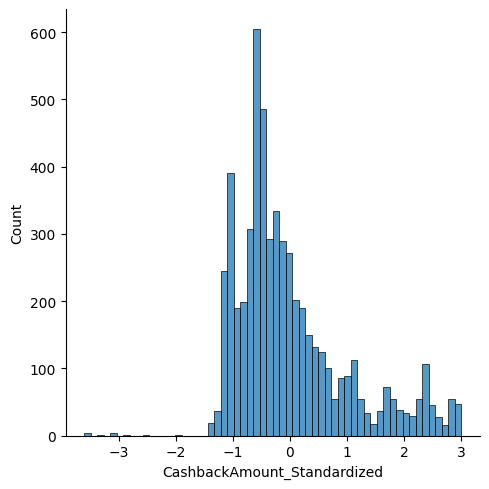

In [6]:
# Standardization (Z-score Normalization)
scaler = StandardScaler()
data['CashbackAmount_Standardized'] = scaler.fit_transform(data[['CashbackAmount']])
# To plot the distribution of 'CashbackAmount' after standardization
sns.displot(data['CashbackAmount_Standardized'])
plt.show()

In [8]:
# Fill null values with the mean of the 'CashbackAmount' column
data['CashbackAmount'].fillna(data['CashbackAmount'].mean())


0       159.93
1       120.90
2       120.28
3       134.07
4       129.60
         ...  
5625    150.71
5626    224.91
5627    186.42
5628    178.90
5629    169.04
Name: CashbackAmount, Length: 5630, dtype: float64

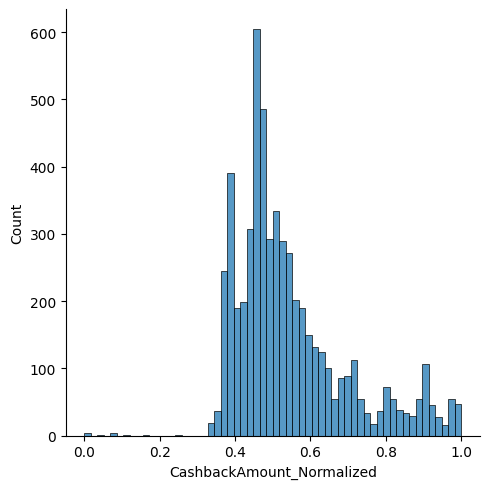

In [10]:
# Normalization (Min-Max Scaling)
min_max_scaler = MinMaxScaler()
data['CashbackAmount_Normalized'] = min_max_scaler.fit_transform(data[['CashbackAmount']])
# To plot the distribution of 'CashbackAmount' after normalization
sns.displot(data['CashbackAmount_Normalized'])
plt.show()


In [11]:
# To save standardized and normalized data to a in existing excel file
with pd.ExcelWriter(r"C:\Users\MUSKAAN\Documents\M.E Folder\ML&AI\Machine Learning Journey\ml-from-basics-to-beyond\Phase_2_Data_Handling\E Commerce Dataset.xlsx", mode='a', if_sheet_exists='replace') as writer:
    data.to_excel(writer, sheet_name='E Comm', index=False)

In [12]:
data.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,CashbackAmount_Standardized,CashbackAmount_Normalized
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000,5.630000e+03,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030,4.038609e-17,0.545318
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036,1.000089e+00,0.151411
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000,-3.601899e+00,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000,-6.392546e-01,0.448537
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000,-2.833796e-01,0.502415
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500,3.896023e-01,0.604303
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000,3.003231e+00,1.000000


In [13]:
data.head(5)

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,...,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,CashbackAmount_Standardized,CashbackAmount_Normalized
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,...,Single,9,1,11.0,1.0,1.0,5.0,159.93,-0.351465,0.492107
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,...,Single,7,1,15.0,0.0,1.0,0.0,120.90,-1.144715,0.372011
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,...,Single,6,1,14.0,0.0,1.0,3.0,120.28,-1.157316,0.370104
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,...,Single,8,0,23.0,0.0,1.0,3.0,134.07,-0.877047,0.412536
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,...,Single,3,0,11.0,1.0,1.0,3.0,129.60,-0.967895,0.398782
